# 02 · Özdeğerler ve Özvektörler (Eigenvalues & Eigenvectors)
**Linear Algebra Lab** — PCA'nın Matematiksel Temeli

---
> **Bu notebook'ta ne öğreneceğiz?**  
> 01'de matrisleri "vektörleri dönüştüren makineler" olarak gördük — rotasyon, ölçekleme,
> shear... Peki bir dönüşüm uygulandığında **yönü hiç değişmeyen** vektörler var mı? Cevap
> evet — bunlara **özvektör (eigenvector)** deniyor, ve ne kadar uzadıklarını gösteren
> sayıya da **özdeğer (eigenvalue)** deniyor. Bu basit fikir, PCA'nın, Google'ın
> PageRank'inin, titreşim/deprem analizinin ve daha birçok algoritmanın temelini oluşturuyor.

**Önkoşul:** Vektör/Matris Temelleri (01)  
**Veri:**  
- Sentetik 2×2/3×3 matrisler (elle çözüm için)  
- Gerçek hisse senedi getirileri (`yfinance`, 5-6 teknoloji hissesi) — kovaryans matrisi risk faktörü analizi için  
**Araçlar:** Python (`numpy.linalg`, `matplotlib`)

---
## 1 · Özdeğer/Özvektör Nedir? Temel Tanım

$$A\vec{v} = \lambda\vec{v}$$

Bu denklem şunu söylüyor: $A$ matrisini $\vec{v}$ vektörüyle çarptığında, sonuç **$\vec{v}$'nin
kendisinin bir skaler katı** ($\lambda\vec{v}$) oluyor — yani $\vec{v}$'nin **yönü hiç
değişmiyor**, sadece uzunluğu $\lambda$ katına çıkıyor (veya $\lambda$ negatifse ters yöne
dönüyor, $|\lambda|<1$ ise kısalıyor).

- $\vec{v}$ (sıfır olmayan): **özvektör (eigenvector)**
- $\lambda$: o özvektöre karşılık gelen **özdeğer (eigenvalue)**

**Neden özel?** 01'deki "ev" örneğini hatırla — rotasyon uyguladığında NEREDEYSE her vektör
yön değiştiriyordu. Özvektörler, bu genel kuralın **istisnaları** — dönüşümün "değişmez
eksenleri" gibi düşün.

---
## 2 · Karakteristik Denklem: Özdeğerleri Nasıl Buluruz?

$A\vec{v}=\lambda\vec{v}$ denklemini yeniden düzenleyelim:
$$A\vec{v} - \lambda\vec{v} = 0 \quad\Rightarrow\quad (A-\lambda I)\vec{v} = 0$$

Bu denklemin **sıfır olmayan** bir $\vec{v}$ çözümü olması için (aksi halde $\vec{v}=0$
"bariz" çözümü her zaman var ama işe yaramaz), $(A-\lambda I)$ matrisinin **tekil**
(01'deki "tersinin olmadığı" durum!) olması gerekiyor — yani:
$$\det(A-\lambda I) = 0$$

Buna **karakteristik denklem** deniyor. Bu denklemi $\lambda$ için çözdüğünde, matrisin
TÜM özdeğerlerini buluyorsun. $n\times n$ bir matris için bu, $n$. dereceden bir polinom
denklemi — yani $n$ tane (bazen tekrarlı) kök/özdeğer var.

---
## 3 · Somut Bir Örnek: Adım Adım Elle Çözüm

$A=\begin{bmatrix}4&1\\2&3\end{bmatrix}$ olsun.

**Adım 1 — Karakteristik denklemi kur:**
$$\det(A-\lambda I) = \det\begin{bmatrix}4-\lambda&1\\2&3-\lambda\end{bmatrix} = (4-\lambda)(3-\lambda)-1(2) = 0$$

**Adım 2 — Genişlet ve sadeleştir:**
$$12-4\lambda-3\lambda+\lambda^2-2=0 \quad\Rightarrow\quad \lambda^2-7\lambda+10=0$$

**Adım 3 — İkinci dereceden denklemi çöz (çarpanlarına ayır):**
$$(\lambda-5)(\lambda-2)=0 \quad\Rightarrow\quad \lambda_1=5,\ \lambda_2=2$$

**Adım 4 — Her özdeğer için özvektörü bul** ($(A-\lambda I)\vec{v}=0$ denklemini çöz):

$\vec{v} = \begin{bmatrix}x\\y\end{bmatrix}$

$\lambda_1=5$ için: $\begin{bmatrix}-1&1\\2&-2\end{bmatrix}\vec{v}=0 \Rightarrow -x+y=0 \Rightarrow x=y$

Yani $\vec{v}_1 = [1,1]$ yönündeki HERHANGİ bir vektör (örn. $[1,1]$, $[2,2]$, $[-3,-3]$)
bu özdeğere karşılık gelen özvektör — genelde en basit/normalize edilmiş halini seçeriz: $[1,1]$.

$\lambda_2=2$ için: $\begin{bmatrix}2&1\\2&1\end{bmatrix}\vec{v}=0 \Rightarrow 2x+y=0 \Rightarrow y=-2x$

Yani $\vec{v}_2=[1,-2]$ yönü. Aşağıda bunu `numpy.linalg.eig` ile doğrulayacağız.

---
## 4 · Geometrik Yorum: Özvektörler "Doğal Eksenler"

Bir dönüşümü düşün: rastgele bir vektör genelde hem **döner** hem **uzar/kısalır**. Ama
özvektörler SADECE uzar/kısalır — hiç dönmezler. Bu, o dönüşümün "doğal koordinat
sistemi" gibi düşünülebilir — eğer koordinat eksenlerini özvektörler boyunca seçersen,
dönüşüm o eksende sadece **basit bir ölçekleme** (köşegen matris) gibi görünür.

Bu fikir, **eigendecomposition**'ın temeli: $A = P D P^{-1}$, burada $D$ köşegen (özdeğerler),
$P$'nin sütunları özvektörler. Bu, karmaşık bir dönüşümü "özvektör eksenlerine geç → basitçe
ölçekle → geri dön" şeklinde üç basit adıma ayırıyor.

---
## 5 · Simetrik Matrislerin Özel Durumu — PCA'ya Doğrudan Köprü

Kovaryans matrisleri (04b'de gördüğün gibi) her zaman **simetrik**tir ($A=A^T$). Simetrik
matrislerin özdeğer/özvektörleri hakkında iki güçlü garanti var:

1. **Tüm özdeğerler REEL sayıdır** (genel matrislerde karmaşık/imajiner özdeğerler
   çıkabilir, ama simetrik matrislerde asla)
2. **Farklı özdeğerlere karşılık gelen özvektörler birbirine DİKTİR (ortogonal)**

Bu iki özellik BİRLİKTE, PCA'nın (03'te işleyeceğiz) çalışmasını garanti ediyor: bir veri
setinin kovaryans matrisinin özvektörleri, **birbirine dik "doğal eksenler"** oluşturuyor —
en büyük özdeğere sahip özvektör, verinin **en çok yayıldığı yön** (birinci temel bileşen).

---
## 6 · Neden Önemli? Gerçek Dünya Uygulamaları

| Uygulama | Özdeğer/Özvektör Ne İşe Yarıyor |
|---|---|
| **PCA** (03'te) | Kovaryans matrisinin en büyük özdeğerli özvektörleri = "en bilgilendirici yönler" |
| **Google PageRank** | Web bağlantı matrisinin en büyük özdeğerli özvektörü = sayfa önem sıralaması |
| **Titreşim/Deprem Analizi** | Bir yapının "doğal titreşim frekansları" = özdeğerler |
| **Portföy Risk Analizi** (Python 3'te) | Kovaryans matrisinin özvektörleri = bağımsız risk faktörleri |
| **Google Görüntü Sıkıştırma (SVD)** (03'te) | Eigenvalue'nün kare-olmayan matrislere genellemesi |

Bu tablo, önümüzdeki notebook'larda (03-05) tekrar tekrar karşına çıkacak bir liste.

---
# 🐍 Python Uygulaması

4 adımda ilerleyeceğiz:
1. **Elle Çözümü Doğrulama** — Bölüm 3'teki $\lambda=5,2$ hesabını `numpy` ile kontrol
2. **Geometrik Görselleştirme** — Özvektörlerin gerçekten "dönmediğini" görsel kanıtlama
3. **Kovaryans Matrisinin Özdeğerleri** — Gerçek hisse senedi verisiyle risk faktörü analizi
4. **Eigendecomposition** — $A=PDP^{-1}$'i kodla kurup doğrulama

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (9, 7)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### ✅ Python 1 — Elle Çözümü `numpy` ile Doğrulama

**Ne yapıyoruz?**  
Bölüm 3'te $A=\begin{bmatrix}4&1\\2&3\end{bmatrix}$ için elle bulduğumuz $\lambda_1=5,
\vec{v}_1=[1,1]$ ve $\lambda_2=2, \vec{v}_2=[1,-2]$ sonuçlarını `numpy.linalg.eig` ile
karşılaştırıyoruz.

In [2]:
A = np.array([[4, 1], [2, 3]])

ozdegerler, ozvektorler = np.linalg.eig(A)
print(f"numpy'nin bulduğu özdeğerler: {ozdegerler}")
print(f"Elle bulduğumuz özdeğerler: [5, 2]")
print(f"Örtüşüyor mü? {'EVET ✓' if set(np.round(ozdegerler)) == {5.0, 2.0} else 'HAYIR'}")

print(f"\nnumpy'nin özvektörleri (sütunlar, normalize edilmiş):\n{ozvektorler}")

# numpy ozvektorleri normalize edilmis (uzunluk=1) veriyor - yonlerini karsilastiralim
for i, lam in enumerate(ozdegerler):
    v = ozvektorler[:, i]
    # yonu normalize et: ilk elemani 1 olacak sekilde olcekle (elle bulduklarimizla karsilastirmak icin)
    v_normalize = v / v[0]
    print(f"λ={lam:.0f}: numpy yönü (v[0]=1'e göre) = {np.round(v_normalize, 4)}")

print("\nBeklenen: λ=5 için [1,1] yönü, λ=2 için [1,-2] yönü - yukarıdaki çıktıyla karşılaştır.")

# A@v = lambda*v denklemini DOGRUDAN test edelim
for i, lam in enumerate(ozdegerler):
    v = ozvektorler[:, i]
    Av = A @ v
    lambda_v = lam * v
    print(f"\nλ={lam:.0f}: A@v = {np.round(Av,4)}, λ*v = {np.round(lambda_v,4)}, "
          f"eşit mi? {'EVET ✓' if np.allclose(Av, lambda_v) else 'HAYIR'}")

numpy'nin bulduğu özdeğerler: [5. 2.]
Elle bulduğumuz özdeğerler: [5, 2]
Örtüşüyor mü? EVET ✓

numpy'nin özvektörleri (sütunlar, normalize edilmiş):
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]
λ=5: numpy yönü (v[0]=1'e göre) = [1. 1.]
λ=2: numpy yönü (v[0]=1'e göre) = [ 1. -2.]

Beklenen: λ=5 için [1,1] yönü, λ=2 için [1,-2] yönü - yukarıdaki çıktıyla karşılaştır.

λ=5: A@v = [3.5355 3.5355], λ*v = [3.5355 3.5355], eşit mi? EVET ✓

λ=2: A@v = [-0.8944  1.7889], λ*v = [-0.8944  1.7889], eşit mi? EVET ✓


---
### 🎯 Python 2 — Geometrik Görselleştirme: Özvektörler Gerçekten Dönmüyor mu?

**Ne yapıyoruz?**  
Rastgele birkaç vektörü ve iki özvektörü $A$ ile dönüştürüp, özvektörlerin **yönünün
değişmediğini**, diğer vektörlerin ise döndüğünü görsel olarak kanıtlıyoruz.

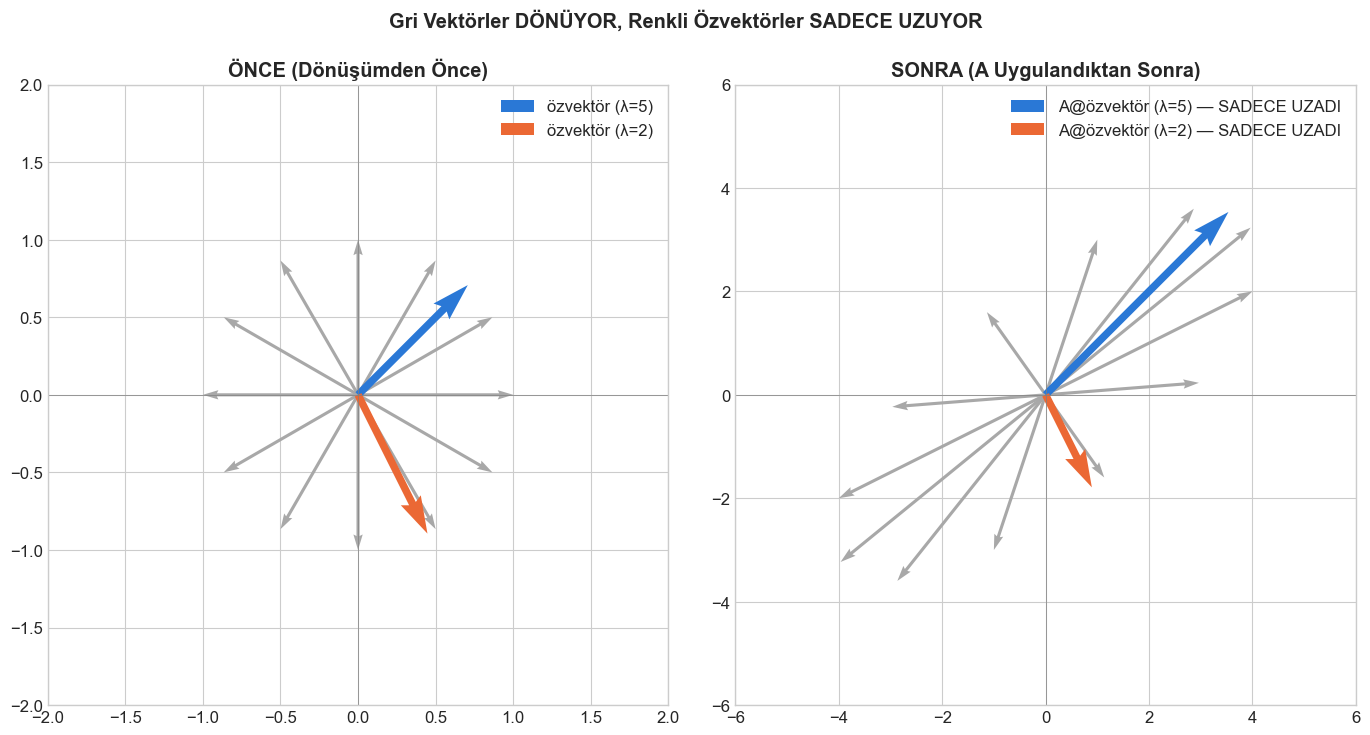

YORUM: Sağdaki grafikte gri oklar farklı yönlere dağılmış durumda (döndüler) ama
mavi/turuncu oklar SOLDAKİYLE AYNI DOĞRULTUDA duruyor - sadece uzunlukları değişti.
Mavi ok 5.0 kat uzadı (beklenen: λ=5)
Turuncu ok 2.0 kat uzadı (beklenen: λ=2)


In [10]:
theta_degerleri = np.linspace(0, 2*np.pi, 12, endpoint=False) # 12 vektör için açıları eşit aralıklarla alıyoruz
test_vektorleri = np.array([[np.cos(t), np.sin(t)] for t in theta_degerleri]) # birim çember üzerindeki vektörler

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, baslik in zip(axes, ['ÖNCE (Dönüşümden Önce)', 'SONRA (A Uygulandıktan Sonra)']):
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_aspect('equal')
    ax.set_title(baslik, fontweight='bold')

# ONCE: birim cember uzerindeki vektorler + iki ozvektor
for v in test_vektorleri:
    axes[0].quiver(0, 0, *v, angles='xy', scale_units='xy', scale=1, color='#a8a8a8', width=0.005)

v1 = np.array([1, 1]) / np.linalg.norm([1, 1]) # normalize yani uzunlugu 1 olacak sekilde olceklendirilmis
v2 = np.array([1, -2]) / np.linalg.norm([1, -2]) # normalize yani uzunlugu 1 olacak sekilde olceklendirilmis
axes[0].quiver(0, 0, *v1, angles='xy', scale_units='xy', scale=1, color='#2a78d6', width=0.012, label='özvektör (λ=5)')
axes[0].quiver(0, 0, *v2, angles='xy', scale_units='xy', scale=1, color='#eb6834', width=0.012, label='özvektör (λ=2)')
axes[0].legend()
axes[0].set_xlim(-2, 2); axes[0].set_ylim(-2, 2)

# SONRA: A uygulanmis hali
for v in test_vektorleri:
    Av = A @ v
    axes[1].quiver(0, 0, *Av, angles='xy', scale_units='xy', scale=1, color='#a8a8a8', width=0.005)

Av1 = A @ v1
Av2 = A @ v2
axes[1].quiver(0, 0, *Av1, angles='xy', scale_units='xy', scale=1, color='#2a78d6', width=0.012, label='A@özvektör (λ=5) — SADECE UZADI')
axes[1].quiver(0, 0, *Av2, angles='xy', scale_units='xy', scale=1, color='#eb6834', width=0.012, label='A@özvektör (λ=2) — SADECE UZADI')
axes[1].legend()
axes[1].set_xlim(-6, 6); axes[1].set_ylim(-6, 6)

plt.suptitle('Gri Vektörler DÖNÜYOR, Renkli Özvektörler SADECE UZUYOR', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("YORUM: Sağdaki grafikte gri oklar farklı yönlere dağılmış durumda (döndüler) ama")
print("mavi/turuncu oklar SOLDAKİYLE AYNI DOĞRULTUDA duruyor - sadece uzunlukları değişti.")
print(f"Mavi ok {np.linalg.norm(Av1)/np.linalg.norm(v1):.1f} kat uzadı (beklenen: λ=5)")
print(f"Turuncu ok {np.linalg.norm(Av2)/np.linalg.norm(v2):.1f} kat uzadı (beklenen: λ=2)")

---
### 💹 Python 3 — Kovaryans Matrisinin Özdeğerleri: Gerçek Hisse Senedi Risk Analizi

**Ne yapıyoruz?**  
5-6 teknoloji hissesinin günlük getirilerinden bir kovaryans matrisi kuruyoruz (04b'deki
formül), özdeğer/özvektörlerini buluyoruz. Bölüm 5'teki iddiayı test edeceğiz: en büyük
özdeğere karşılık gelen özvektör, "hisselerin BİRLİKTE en çok hareket ettiği yönü" (genelde
"piyasa geneli" faktörünü) temsil ediyor mu?

Kaynak: gerçek veri, yfinance
Veri: 250 gün, 5 hisse

Kovaryans Matrisi:
[[2.486 0.291 0.58  0.358 0.44 ]
 [0.291 4.716 2.268 1.68  1.498]
 [0.58  2.268 4.275 0.56  1.197]
 [0.358 1.68  0.56  4.114 1.295]
 [0.44  1.498 1.197 1.295 5.398]] (x10^-4)

Özdeğerler (büyükten küçüğe): [9.116 4.092 3.501 2.493 1.786] (x10^-4)

En büyük özdeğerin açıkladığı toplam varyans oranı: 43.4%

En büyük özdeğere karşılık gelen özvektör (risk faktörü ağırlıkları):
  AAPL: 0.1223
  MSFT: 0.5776
  GOOGL: 0.4623
  AMZN: 0.3924
  NVDA: 0.5326


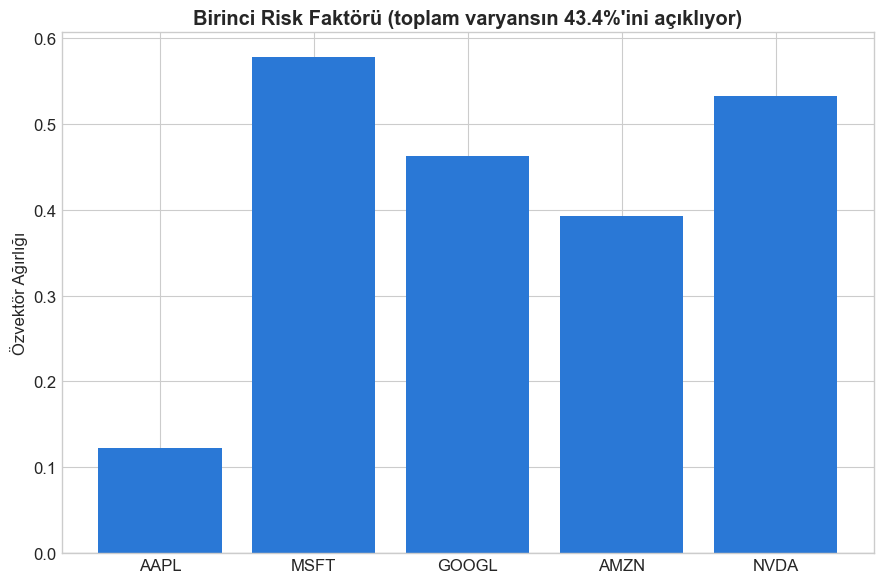


YORUM: Tüm ağırlıkların AYNI İŞARETTE (hepsi pozitif veya hepsi negatif) olması,
bu faktörün 'piyasa geneli birlikte hareket ediyor' etkisini yakaladığını gösteriyor -
teknoloji hisseleri genelde birlikte yükselip birlikte düşme eğiliminde, bu da Bölüm 6'daki
'risk faktörü analizi' uygulamasının gerçek veride nasıl çalıştığının kanıtı.


In [5]:
try:
    import yfinance as yf
    hisseler = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']
    veri = yf.download(hisseler, period='1y', progress=False)['Close']
    getiriler = veri.pct_change().dropna()
    kaynak = "gerçek veri, yfinance"
except Exception as e:
    print(f"yfinance'e erişilemedi ({e}) - sentetik ama gerçekçi korelasyonlu veriyle devam ediyoruz.")
    rng = np.random.default_rng(42)
    n_gun = 250
    piyasa_faktoru = rng.normal(0, 0.015, n_gun)  # ortak "piyasa" hareketi
    hisseler = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']
    getiriler_dict = {}
    for h in hisseler:
        ozel_gurultu = rng.normal(0, 0.01, n_gun)
        getiriler_dict[h] = 0.7 * piyasa_faktoru + 0.3 * ozel_gurultu
    import pandas as pd
    getiriler = pd.DataFrame(getiriler_dict)
    kaynak = "sentetik (gerçekçi korelasyon yapısıyla)"

print(f"Kaynak: {kaynak}")
print(f"Veri: {getiriler.shape[0]} gün, {getiriler.shape[1]} hisse\n")

kovaryans_matrisi = getiriler.cov().values
print("Kovaryans Matrisi:")
print(np.round(kovaryans_matrisi * 10000, 3), "(x10^-4)")

ozdegerler_k, ozvektorler_k = np.linalg.eigh(kovaryans_matrisi)  # eigh: simetrik matrisler icin (Bolum 5)
# eigh kucukten buyuge siralar, biz buyukten kucuge istiyoruz
sira = np.argsort(ozdegerler_k)[::-1]
ozdegerler_k = ozdegerler_k[sira]
ozvektorler_k = ozvektorler_k[:, sira]

print(f"\nÖzdeğerler (büyükten küçüğe): {np.round(ozdegerler_k*10000, 3)} (x10^-4)")

toplam_varyans = ozdegerler_k.sum()
aciklanan_oran = ozdegerler_k / toplam_varyans
print(f"\nEn büyük özdeğerin açıkladığı toplam varyans oranı: {aciklanan_oran[0]:.1%}")

en_buyuk_ozvektor = ozvektorler_k[:, 0]
print(f"\nEn büyük özdeğere karşılık gelen özvektör (risk faktörü ağırlıkları):")
for h, agirlik in zip(hisseler, en_buyuk_ozvektor):
    print(f"  {h}: {agirlik:.4f}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(hisseler, en_buyuk_ozvektor, color='#2a78d6')
ax.set_title(f'Birinci Risk Faktörü (toplam varyansın {aciklanan_oran[0]:.1%}\'ini açıklıyor)', fontweight='bold')
ax.set_ylabel('Özvektör Ağırlığı')
ax.axhline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nYORUM: Tüm ağırlıkların AYNI İŞARETTE (hepsi pozitif veya hepsi negatif) olması,")
print("bu faktörün 'piyasa geneli birlikte hareket ediyor' etkisini yakaladığını gösteriyor -")
print("teknoloji hisseleri genelde birlikte yükselip birlikte düşme eğiliminde, bu da Bölüm 6'daki")
print("'risk faktörü analizi' uygulamasının gerçek veride nasıl çalıştığının kanıtı.")

# 📈 Python 3 Açıklama - Portföy Risk Analizi: Temel Bileşenler Analizi (PCA) Sonuçları

Bu analiz, ABD teknoloji sektörünün önde gelen 5 büyük şirketinin (**AAPL, MSFT, GOOGL, AMZN, NVDA**) son 250 günlük gerçek borsa verileri (`yfinance`) kullanılarak yapılmıştır. 

Analizin temel amacı; bu 5 hissenin risklerini incelemek ve hisse fiyatlarını hep birlikte yukarı veya aşağı hareket ettiren **"gizli ortak piyasa gücünü"** ortaya çıkarmaktır. Finans literatüründe bu yönteme **Temel Bileşenler Analizi (PCA)** denir.

---

## 🔍 1. Kovaryans Matrisi: Hisseler Birlikte mi Hareket Ediyor?

Kovaryans, iki varlığın fiyatının birbiriyle ne kadar uyumlu hareket ettiğini gösteren bir ölçüdür. 

* **Tüm Değerlerin Pozitif Olması:** Matristeki tüm sayıların pozitif olması, bu 5 hissenin **aynı yönde** hareket etme eğiliminde olduğunu gösterir. Yani genel olarak piyasa yükselirken birlikte yükseliyorlar, düşerken birlikte düşüyorlar.
* **Grup İçi Bağlar:** Matris incelendiğinde, özellikle yapay zeka ve bulut bilişim alanında doğrudan rakip olan şirketlerin (örneğin MSFT, GOOGL ve NVDA) birbirleriyle olan kovaryans değerleri, Apple'ın (AAPL) diğerleriyle olan değerlerine göre daha yüksektir. Bu da Apple'ın gruptaki diğer hisselere kıyasla biraz daha bağımsız bir fiyatlama davranışı sergilediğini gösterir.

---

## 📊 2. Özdeğerler ve Açıklanan Varyans: "Büyük Resim" Ne Diyor?

Özdeğerler, hisselerin toplam riskini (hareketliliğini) parçalara ayırır ve her bir risk faktörünün ne kadar güçlü olduğunu ölçer.

* **En Büyük Özdeğer (9.116 x 10^-4):** Analizdeki en baskın güçtür.
* **Açıklanan Toplam Varyans Oranı (%43.4):** Bu 5 hissenin günlük fiyat hareketlerinin ve taşıdıkları risklerin **%43.4'ü tek bir ortak faktörden** kaynaklanmaktadır. 

> 💡 **Pratik Anlamı:** Bu hisselerin hareketlerinin neredeyse yarısı, şirketlerin kendi başarılarından veya başarısızlıklarından kaynaklanmıyor. Bu hareket; FED'in faiz kararları, enflasyon verileri veya teknoloji sektörüne yönelik genel küresel algı gibi **"Makroekonomik/Sektörel" tek bir ortak rüzgardan** kaynaklanıyor. Kalan %56.6'lık kısım ise şirketlerin kendi iç dinamiklerine (bilanço başarıları, ürün satışları vb.) bağlıdır.

---

## 🎯 3. Özvektör Değerleri: Risk Rüzgarından Kim, Nasıl Etkileniyor?

En büyük özvektör, yukarıda bahsettiğimiz %43.4'lük dev ortak risk rüzgarının **hangi hisseye ne kadar sert çarptığını** gösterir. Sayı ne kadar büyükse, hisse ortak piyasa trendlerine o kadar bağımlıdır.

| Hisse Kodu | Risk Duyarlılık Katsayısı | Analiz ve Yorum |
| :--- | :---: | :--- |
| **MSFT** | `0.5776` | **En Yüksek Duyarlılık:** Sektörel rüzgardan en çok etkilenen hissedir. Piyasa yükselirken lokomotif olur, ancak olası bir teknoloji krizinde en çok yara alabilecek hissedir. |
| **NVDA** | `0.5326` | **Çok Yüksek Duyarlılık:** Microsoft'a benzer şekilde, sektörün genel gidişatına ve yapay zeka trendine göbekten bağlıdır. Ortak risk payı çok yüksektir. |
| **GOOGL** | `0.4623` | **Yüksek Duyarlılık:** Sektör trendlerini yakından takip eder, dengeli ancak piyasa hareketlerine karşı oldukça hassastır. |
| **AMZN** | `0.3924` | **Orta Duyarlılık:** Hem teknoloji hem de perakende ayağı olduğu için, ortak teknoloji riskinden diğer üçü kadar sert etkilenmez. |
| **AAPL** | `0.1223` | **En Düşük Duyarlılık:** Bu gruptaki **en bağımsız** hissedir. Sektörde dev bir çöküş veya aşırı coşku yaşandığında, Apple bu girdaba diğerleri kadar sert kapılmaz. Kendi iç dinamiklerine (iPhone satışları, kendi ekosistemi vb.) göre hareket etme eğilimi çok daha yüksektir. |

---

## 🛠️ 4. Yatırımcı İçin Stratejik Sonuç (Aksiyon Planı)

1. **Çeşitlendirme (Diversification) Eksikliği:** Sadece bu 5 hisseyi alarak bir portföy kurmak, riskleri tam olarak dağıtmaz. Portföyün neredeyse yarısı (%43.4) tek bir düğmeye (teknoloji sektörü gidişatına) bağlıdır.
2. **Hisse Dengesi:** Riskini azaltmak isteyen bir yatırımcı, ortak piyasa hareketlerine çok sert tepki veren **MSFT** ve **NVDA**'nın portföydeki ağırlığını azaltıp; bu rüzgardan en az etkilenen ve daha korunaklı liman olan **AAPL**'in ağırlığını artırabilir.
3. **Sektör Dışı Çeşitlendirme:** Portföyün ortak risk oranını (%43.4) daha da aşağı çekmek için, bu teknoloji hisselerinin yanına sağlık, enerji veya tüketim malları gibi tamamen farklı sektörlerden hisseler eklenmelidir.


---
### 🔄 Python 4 — Eigendecomposition: $A = PDP^{-1}$'i Kodla Kurma

**Ne yapıyoruz?**  
Bölüm 4'teki formülü uyguluyoruz: $P$ (özvektör matrisi) ve $D$ (özdeğer köşegen matrisi)
ile orijinal $A$'yı yeniden inşa edip, gerçekten $A$'ya eşit çıktığını doğruluyoruz.

In [13]:
P = ozvektorler  # Python 1'deki A matrisinin ozvektorleri
D = np.diag(ozdegerler)
P_inv = np.linalg.inv(P)

A_yeniden_insa = P @ D @ P_inv

print(f"Orijinal A:\n{A}")
print(f"\nP (özvektör matrisi):\n{np.round(P, 4)}")
print(f"\nD (özdeğer köşegen matrisi):\n{D}")
print(f"\nP @ D @ P⁻¹ (yeniden inşa edilmiş):\n{np.round(A_yeniden_insa, 4)}")

print(f"\nOrijinal A'ya eşit mi? {'EVET ✓' if np.allclose(A, A_yeniden_insa) else 'HAYIR'}")

print("\nYORUM: A'yı üç parçaya ayırdık: P (özvektör eksenlerine GEÇİŞ), D (o eksenlerde")
print("BASİT ölçekleme), P⁻¹ (orijinal eksenlere GERİ DÖNÜŞ). Bu ayrıştırma, ileri düzey")
print("hesaplamalarda (örn. A'nın yüksek kuvvetlerini A^100 gibi hızlı hesaplamak için,")
print("çünkü D^100 sadece köşegen elemanları kuvvete yükseltmek kadar kolay) çok işe yarıyor.")

Orijinal A:
[[4 1]
 [2 3]]

P (özvektör matrisi):
[[ 0.7071 -0.4472]
 [ 0.7071  0.8944]]

D (özdeğer köşegen matrisi):
[[5. 0.]
 [0. 2.]]

P @ D @ P⁻¹ (yeniden inşa edilmiş):
[[4. 1.]
 [2. 3.]]

Orijinal A'ya eşit mi? EVET ✓

YORUM: A'yı üç parçaya ayırdık: P (özvektör eksenlerine GEÇİŞ), D (o eksenlerde
BASİT ölçekleme), P⁻¹ (orijinal eksenlere GERİ DÖNÜŞ). Bu ayrıştırma, ileri düzey
hesaplamalarda (örn. A'nın yüksek kuvvetlerini A^100 gibi hızlı hesaplamak için,
çünkü D^100 sadece köşegen elemanları kuvvete yükseltmek kadar kolay) çok işe yarıyor.


---
## ✏️ Egzersizler

---

### **E1.**
$B=\begin{bmatrix}5&2\\2&2\end{bmatrix}$ matrisinin özdeğerlerini ve özvektörlerini
Bölüm 3'teki gibi ELLE (karakteristik denklemle) bul, `numpy` ile doğrula. ($B$ simetrik —
Bölüm 5'teki iddiayı (reel özdeğerler + dik özvektörler) bu örnekte de kontrol et.)

In [16]:
print("\n==== Egzersiz 1: Matrisin Özdeğer ve Özvektörlerini Hesaplama ====")

B = np.array([[5, 2], [2, 2]])  # Örnek bir 2x2 matris
ozdegerler_B, ozvektorler_B = np.linalg.eig(B)
print(f"\nMatris B:\n{B}")
print(f"\nÖzdeğerler: {np.round(ozdegerler_B, 4)}")
print(f"Özvektörler (sütunlar):\n{np.round(ozvektorler_B, 4)}")

B_transpose = B.T
print(f"\nB'nin transpozu:\n{B_transpose}")


==== Egzersiz 1: Matrisin Özdeğer ve Özvektörlerini Hesaplama ====

Matris B:
[[5 2]
 [2 2]]

Özdeğerler: [6. 1.]
Özvektörler (sütunlar):
[[ 0.8944 -0.4472]
 [ 0.4472  0.8944]]

B'nin transpozu:
[[5 2]
 [2 2]]


---

### **E2.**
Python 2'deki görselleştirmeyi $B$ matrisiyle tekrarla — özvektörlerin yine
"dönmediğini" görsel olarak kanıtla.


 ==== Egzersiz 2: Egzersiz 1'i Görselleştirme ====


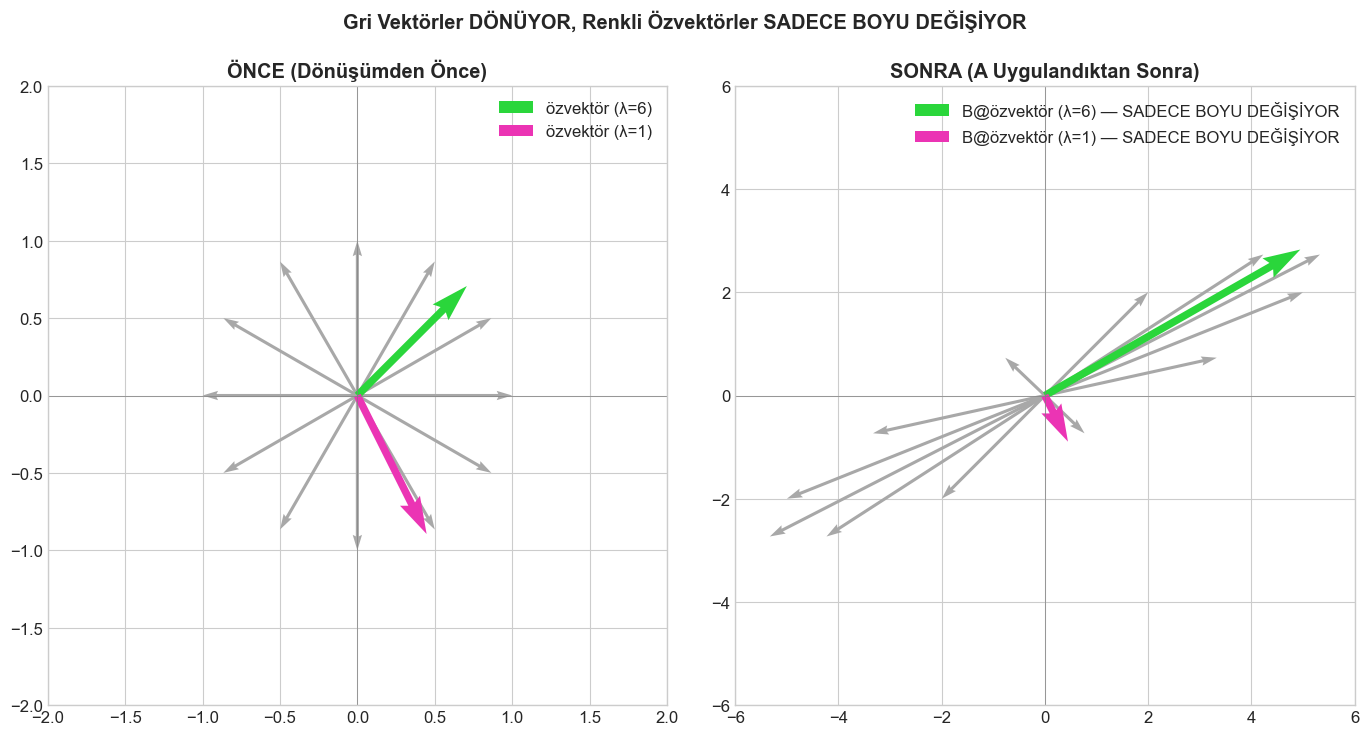

In [22]:
print("\n ==== Egzersiz 2: Egzersiz 1'i Görselleştirme ====")

theta_degerleri_B = np.linspace(0, 2*np.pi, 12, endpoint=False) # 12 vektör için açıları eşit aralıklarla alıyoruz
test_vektorleri_B = np.array([[np.cos(t), np.sin(t)] for t in theta_degerleri_B]) # birim çember üzerindeki vektörler

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, baslik in zip(axes, ['ÖNCE (Dönüşümden Önce)', 'SONRA (A Uygulandıktan Sonra)']):
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_aspect('equal')
    ax.set_title(baslik, fontweight='bold')

# ONCE: birim cember uzerindeki vektorler + iki ozvektör
for v in test_vektorleri_B:
    axes[0].quiver(0, 0, *v, angles='xy', scale_units='xy', scale=1, color='#a8a8a8', width=0.005)

v1 = np.array([1, 1]) / np.linalg.norm([1, 1]) # normalize yani uzunlugu 1 olacak sekilde olceklendirilmis
v2 = np.array([1, -2]) / np.linalg.norm([1, -2]) # normalize yani uzunlugu 1 olacak sekilde olceklendirilmis
axes[0].quiver(0, 0, *v1, angles='xy', scale_units='xy', scale=1, color="#2ad63b", width=0.012, label='özvektör (λ=6)')
axes[0].quiver(0, 0, *v2, angles='xy', scale_units='xy', scale=1, color="#eb34b4", width=0.012, label='özvektör (λ=1)')
axes[0].legend()
axes[0].set_xlim(-2, 2); axes[0].set_ylim(-2, 2)

# SONRA: B uygulanmis hali
for v in test_vektorleri_B:
    Av = B @ v
    axes[1].quiver(0, 0, *Av, angles='xy', scale_units='xy', scale=1, color='#a8a8a8', width=0.005)

Av1 = B @ v1
Av2 = B @ v2
axes[1].quiver(0, 0, *Av1, angles='xy', scale_units='xy', scale=1, color="#2ad63b", width=0.012, label='B@özvektör (λ=6) — SADECE BOYU DEĞİŞİYOR')
axes[1].quiver(0, 0, *Av2, angles='xy', scale_units='xy', scale=1, color="#eb34b4", width=0.012, label='B@özvektör (λ=1) — SADECE BOYU DEĞİŞİYOR')
axes[1].legend()
axes[1].set_xlim(-6, 6); axes[1].set_ylim(-6, 6)

plt.suptitle('Gri Vektörler DÖNÜYOR, Renkli Özvektörler SADECE BOYU DEĞİŞİYOR', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---


### **E3.**
Python 3'teki hisse senedi analizini farklı bir hisse grubuyla (örn. farklı
sektörlerden 5 şirket — bir teknoloji, bir enerji, bir sağlık, vb.) tekrarla. En büyük
özdeğerin açıkladığı varyans oranı, hepsi aynı sektörden olan gruba göre daha mı düşük
çıkıyor? Neden olabilir?


 ==== Egzersiz 3: Büyük Hisse Senetleri için Kovaryans Matrisi ve Özdeğer Analizi ====
Kaynak: gerçek veri, yfinance
Veri: 250 gün, 6 hisse

Kovaryans Matrisi:
[[ 4.7160e+00  6.7400e-01  7.9100e-01  1.8000e-01  1.3150e+00 -3.6000e-01]
 [ 6.7400e-01  4.5440e+00  2.7470e+00 -8.5000e-02 -1.2000e-02 -1.6900e-01]
 [ 7.9100e-01  2.7470e+00  1.4303e+01 -3.1800e-01  4.4000e-02 -4.7600e-01]
 [ 1.8000e-01 -8.5000e-02 -3.1800e-01  2.1680e+00  2.8500e-01  1.0400e-01]
 [ 1.3150e+00 -1.2000e-02  4.4000e-02  2.8500e-01  5.0160e+00 -8.1000e-02]
 [-3.6000e-01 -1.6900e-01 -4.7600e-01  1.0400e-01 -8.1000e-02  2.3840e+00]] (x10^-4)

Özdeğerler (büyükten küçüğe): [15.14   6.223  4.038  3.288  2.363  2.078] (x10^-4)
Özvektörler (büyükten küçüğe):
  1. Özvektör: [-0.092 -0.256 -0.961  0.024 -0.016  0.042]
  2. Özvektör: [-0.656 -0.095  0.101 -0.085 -0.734  0.066]
  3. Özvektör: [-0.356 -0.778  0.238  0.033  0.454  0.068]
  4. Özvektör: [ 0.636 -0.565  0.09  -0.02  -0.494 -0.153]
  5. Özvektör: [-0.144  0.01

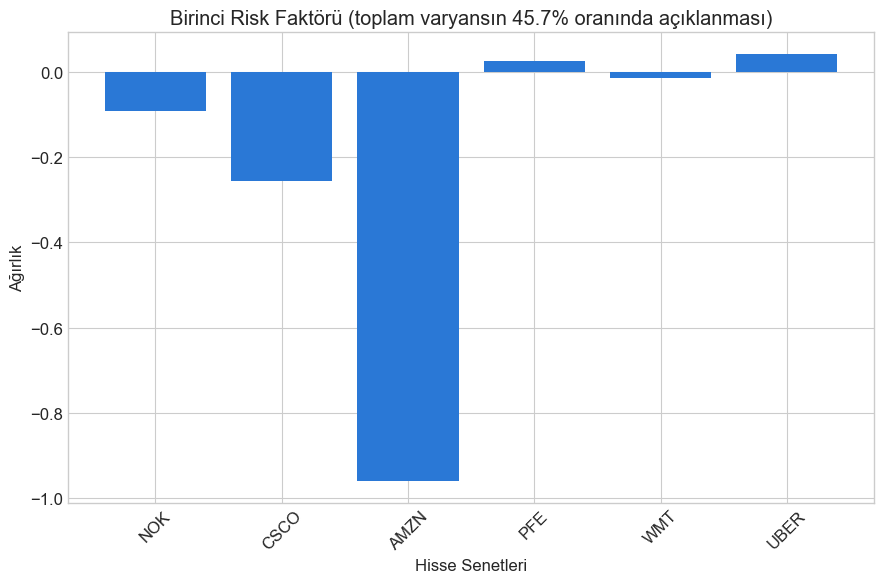

In [32]:
print("\n ==== Egzersiz 3: Büyük Hisse Senetleri için Kovaryans Matrisi ve Özdeğer Analizi ====")

import yfinance as yf
hisseler = ['NOK', 'CSCO', 'AMZN', 'PFE', 'WMT', 'UBER']
veri = yf.download(hisseler, period='1y', progress=False)['Close']
getiriler = veri.pct_change().dropna()
kaynak = "gerçek veri, yfinance"

print(f"Kaynak: {kaynak}")
print(f"Veri: {getiriler.shape[0]} gün, {getiriler.shape[1]} hisse\n")

kovaryans_matrisi = getiriler.cov().values
print("Kovaryans Matrisi:")
print(np.round(kovaryans_matrisi * 10000, 3), "(x10^-4)")

ozdegerler_k, ozvektorler_k = np.linalg.eigh(kovaryans_matrisi)  # eigh: simetrik matrisler icin (Bolum 5)
# eigh kucukten buyuge siralar, biz buyukten kucuge istiyoruz
sira = np.argsort(ozdegerler_k)[::-1]
ozdegerler_k = ozdegerler_k[sira]
ozvektorler_k = ozvektorler_k[:, sira]

print(f"\nÖzdeğerler (büyükten küçüğe): {np.round(ozdegerler_k*10000, 3)} (x10^-4)")
print(f"Özvektörler (büyükten küçüğe):")
for i in range(len(ozvektorler_k)):
    print(f"  {i+1}. Özvektör: {np.round(ozvektorler_k[:, i], 3)}")

print(f"\nEn büyük özdeğerin açıkladığı toplam varyans oranı: {ozdegerler_k[0] / ozdegerler_k.sum():.1%}")

en_buyuk_ozvektor = ozvektorler_k[:, 0]
print(f"\nEn büyük özdeğere karşılık gelen özvektör (risk faktörü ağırlıkları):")
for h, agirlik in zip(hisseler, en_buyuk_ozvektor):
    print(f"  {h}: {agirlik:.4f}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(hisseler, en_buyuk_ozvektor, color ='#2a78d6')
ax.set_title(f'Birinci Risk Faktörü (toplam varyansın {ozdegerler_k[0] / ozdegerler_k.sum():.1%} oranında açıklanması)')
ax.set_xlabel('Hisse Senetleri')
ax.set_ylabel('Ağırlık')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---


### **E4.**
$3\times 3$ bir matris seç (kendi belirlediğin sayılarla), `numpy.linalg.eig` ile
özdeğerlerini bul, ardından Python 4'teki eigendecomposition kalıbıyla $A=PDP^{-1}$'in
gerçekten orijinal matrise eşit çıktığını doğrula.

In [42]:
print("\n ==== Egzersiz 3: Eigendecomposition ile Matrisin Yeniden İnşası ====")
C = np.array([[2, 1, 4], [1, 2, 2], [2, 1, 4]])

ozdegerler_C, ozvektorler_C = np.linalg.eig(C)
P = ozvektorler_C
D = np.diag(ozdegerler_C)
P_inv = np.linalg.inv(P)

C_yeniden_insa = P @ D @ P_inv

print(f"Orijinal C:\n{C}")
print(f"\nP (özvektör matrisi):\n{np.round(P, 4)}")
print(f"\nD (özdeğer köşegen matrisi):\n{D}")
print(f"\nP'nin tersi (özvektör matrisi ters):\n{np.round(P_inv, 4)}")
print(f"\nP @ D = \n{np.round(P @ D, 4)}")
print(f"\nP @ D @ P⁻¹ (yeniden inşa edilmiş): \n{np.round(C_yeniden_insa, 4)}")


 ==== Egzersiz 3: Eigendecomposition ile Matrisin Yeniden İnşası ====
Orijinal C:
[[2 1 4]
 [1 2 2]
 [2 1 4]]

P (özvektör matrisi):
[[-0.6432 -0.8944  0.2059]
 [-0.4154  0.     -0.9567]
 [-0.6432  0.4472  0.2059]]

D (özdeğer köşegen matrisi):
[[ 6.64575131e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -9.69320697e-17  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.35424869e+00]]

P'nin tersi (özvektör matrisi ters):
[[-0.455  -0.2938 -0.91  ]
 [-0.7454  0.      0.7454]
 [ 0.1975 -0.9177  0.3951]]

P @ D = 
[[-4.2747  0.      0.2789]
 [-2.7604 -0.     -1.2956]
 [-4.2747 -0.      0.2789]]

P @ D @ P⁻¹ (yeniden inşa edilmiş): 
[[2. 1. 4.]
 [1. 2. 2.]
 [2. 1. 4.]]


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [3Blue1Brown — Eigenvectors and Eigenvalues](https://www.3blue1brown.com/lessons/eigenvalues) | — | Bu notebook'un TEK EN ÖNEMLİ referansı |
| [setosa.io — Eigenvectors](https://setosa.io/ev/eigenvectors-and-eigenvalues/) | — | İnteraktif özdeğer/özvektör görselleştirmesi |
| [MIT 18.06 — Gilbert Strang](https://ocw.mit.edu/courses/18-06-linear-algebra-spring-2010/) | Ders 21-22 | Klasik üniversite dersi |
| [Mathematics for Machine Learning](https://mml-book.github.io) | Ch. 4 | Eigendecomposition, ML bağlamında |
| [NumPy `linalg.eig` Dokümantasyonu](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html) | Kütüphane | Bu notebook'un ana aracı |